## 05 - Looping Graph

In this notebook we'll do the following:
1. Implement looping logic to route flow back to the nodes
2. Create a single conditional edge to handle decision making and control graph flow

Here is the graph we'll be building:

<div align="center">
<img src="images/05_looping_graph.png" width="300" heigh="550" alt="Looping Graph"/>
</div>

* The 'Greeting Node' will update greeting with a "Hi <state param: name>" message
* The 'Random Node' will generate 'N' random numbers and store in _state param: random_nos_ variable. It will loop _state param: N_ times, each time a new random no is generated and appended to _state param: random_nos_ list variable

This is practially a completely useless graph 😏!

In [54]:
from typing import TypedDict, List, Any
from langgraph.graph import StateGraph, START, END

In [55]:
# Step 1: define the graph state
# define the state that will be passed around
# the graph - it should be an instance of TypedDict
class State(TypedDict):
    name: str  # name user provides
    greeting: str  # updated by 'greeting node'
    num_random: int  # how many random numbers
    counter: int  # running counter to control looping
    random_nos: List[int]  # list of num_random random nos (generated)

In [56]:
# Step 2: build the nodes (functions)
import random


def greeting(state: State) -> dict[str, Any]:
    """updates greering node with greeting message"""
    return {
        # modify greetings
        "greeting": f"Hi there {state['name']}",
        # just a check that N is >0, set to 5 if user sets -ve value
        "num_random": 5 if state["num_random"] < 0 else state["num_random"],
        # initialize remaining
        "counter": 0,
        "random_nos": [],
    }


def random_node(state: State) -> State:
    """generates a random no & appends to random_nos"""
    # generate random no betwee 0 and 100
    random_no = random.randint(0, 10)
    state["random_nos"].append(random_no)
    state["counter"] += 1
    print(f"random_node: generated {state['counter']} random no {random_no}")
    return state


def should_loop_or_exit(state: State) -> State:
    """controls looping count for random node"""
    if state["counter"] >= state["num_random"]:
        return "exit"
    else:
        return "loop"

In [57]:
# build out our graph
builder = StateGraph(State)
builder.add_node("greeting", greeting)
builder.add_node("random_node", random_node)

# add edges (define structure)
builder.add_edge(START, "greeting")
builder.add_edge("greeting", "random_node")
builder.add_conditional_edges(
    "random_node",  # from random no generator
    should_loop_or_exit,  # check if I should loop or not
    {
        # this is like a switch(op_router()) call
        # case "+" -> "addition" etc.
        "loop": "random_node",  # back to random
        "exit": END,
    },
)
graph = builder.compile()

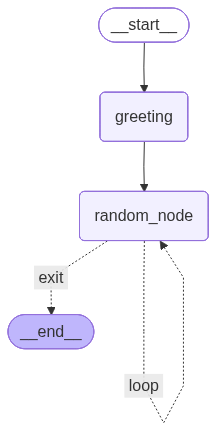

In [58]:
# and let's see how our
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [61]:
# now invoke the graph
# NOTE: the graph is a Runnable, so it has the invoke() function defined
from rich.console import Console

console = Console()

state = State(name="Bilbo Baggins", num_random=7)

response = graph.invoke(state)
console.print(response)

random_node: generated 1 random no 3
random_node: generated 2 random no 2
random_node: generated 3 random no 10
random_node: generated 4 random no 9
random_node: generated 5 random no 8
random_node: generated 6 random no 1
random_node: generated 7 random no 4


{
    'name': 'Bilbo Baggins',
    'greeting': 'Hi there Bilbo Baggins',
    'num_random': 7,
    'counter': 7,
    'random_nos': [3, 2, 10, 9, 8, 1, 4]
}

### Exercise 
Your Task:
1. Build a 2 router graph as shown in the image below
2. The first router either adds/subtracts number1 & number2 and saves result in finalNumber (in State)
3. The second router either adds/subtracts number2 & number4 and saves result in finalNumber2 (in State)

![Plot](images/04_Ex_conditional_graph.png)
